# Prova de Conceito (POC 2.0) - Detecção de EPIs na Construção Civil

Este notebook implementa um modelo abrangente de visão computacional para detectar o uso de Equipamentos de Proteção Individual (EPI) em canteiros de obras. Ele foi construído com base em uma arquitetura robusta de detecção de objetos, adaptada para as necessidades específicas de auditoria de segurança.

**Objetivo:** Identificar automaticamente a presença ou ausência de EPIs obrigatórios com foco na análise de conformidade e auditoria pós-evento.

**Principais Características deste Modelo (POC 1.0):**
*   **Modelo:** Utiliza o **YOLO26n** (You Only Look Once - Versão 26 Nano), um algoritmo de *deep learning* de estágio único conhecido por sua alta eficiência e velocidade, ideal para treinamento e inferência na GPU Nvidia T4 do Google Colab.
*   **Métricas Principais:** O modelo é avaliado com base no **mAP (mean Average Precision)**, **Precisão** e **Revocação (Recall)**, garantindo um bom balanço entre detectar corretamente os EPIs e minimizar falsos positivos/negativos.
*   **Pré-processamento de Imagens:** Não há necessidade de técnicas complexas de processamento prévio (como conversão para escala de cinza ou suavização extrema). As imagens do dataset já estão padronizadas na resolução de **640x640 pixels** e mantidas em **cores (RGB)**. A preservação das cores é fundamental para esta tarefa, pois a detecção de EPIs (especialmente coletes) depende fortemente de cores de alta visibilidade (neon, laranja, amarelo).
*   **Classes Alvo:** O dataset e o modelo estão alinhados para detectar as três classes principais exigidas no ambiente da construção civil: **Capacetes** (*Helmets*), **Coletes de Segurança** (*Safety Vests*), **Botas** (*Boots*), **Máscaras** (*Masks*) e **Luvas** (*Gloves*).
*   **Avaliação Rigorosa:** Inclui análise detalhada de desempenho através de curvas de perda (*loss curves*), matriz de confusão e curva F1-Score geradas nativamente pelo framework Ultralytics para monitorar o aprendizado e evitar *overfitting*.

**Principais Revisões (POC 1.5):**

* **Verificação de balanceamento de classes:** Na nova sessão 1.5 há o geramento de um grafico para verificação de balanceamento das classes do dataset.

*   **Mudanças na sessão 2 (hyperpamentros):** Com base na verificação de balanceamento de classes e na performance da **POC 1.0** em pequenos objetos foi decido o uso de alguns parametros complementares para o treinamento, como:

* **mosaic=1.0:** Junta 4 imagens em 1. Isso reduz o tamanho relativo dos objetos, forçando o modelo a ficar especialista em detectar coisas minúsculas (excelente para luvas/botas).

* **scale=0.5:** Faz zoom in/out aleatório nas imagens.

* **hsv_s e hsv_v:** Altera aleatoriamente a saturação e o brilho. Isso ajuda muito com as botas, que costumam se misturar com a cor do chão ou sombras.

* **box=7.5 padrão** para forçar o modelo a ser mais rigoroso ao desenhar as bounding boxes em objetos difíceis.

* **lr0=0.002:** Aumento da taxa de aprendizado pois o tempo de treinamento é curto, assim forçando o modelo a aprender mais agressivamente no curto espaço de tempo.

* **otimizador AdamW:** Ele é conhecido por convergir mais rápido que o SGD em treinamentos curtos e lida muito bem com modelos pequenos.

**Principais Revisões (POC 1.6):**

* **Demonstração do Pipeline de Processamento (Data Augmentation):** Na nova sessão 4, há a explicação por imagem do pre-processamento de imagem feita pelo modelo com base nos métodos utilizados no treinamento (hyperparametros).

**Principais Revisões (POC 2.0):**

* **Problema de tempo de leitura de disco (I/O Bound):** Na `Nova sessão 1`, há o ajuste para usar o google drive como fonte de dados assim cortando o problema de espera de upload direto ao colab, redução de 40-50mins para segundos.

* **Mudança de treinamento (Sessão 2 - treinamento):** Foram mudados alguns parametros e adionados novos para tentar maximar o uso do harware em relação a tempo de processamento, logo podemos treinar por mais tempo do que o anterior (35 epochs) que atualmente foi aumentado para 50 epochs, por um tempo similar (Ver comentarios no código).

* **Exportação para hugging face (Sessão 6 - Deploy):** Esta parte cobre o as arquivos necessários para exportar e subir o modelo no `Spaces` do hugging face.


## 0. Instalação de Dependências
Primeiro, vamos instalar a biblioteca `ultralytics`, que contém a implementação oficial dos modelos YOLO.

In [ ]:
!pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


## 1. Ingestão de Dados Otimizada (Google Drive)
Para evitar o tempo excessivo de upload pelo navegador (I/O Bound), conectaremos diretamente ao Google Drive. O arquivo `.zip` é transferido internamente pela rede do Google para a máquina virtual do Colab em segundos.

* **Nota:** Vá no google drive e crie uma pasta chamada "EPI_Project" e faça o upload do arquivo do dataset com o nome "dataset.zip" `DETALHE:` tem que ser exatamente este o nome.

In [ ]:
import os
import zipfile
import glob
import yaml
import shutil
from google.colab import drive

# 1. Conecta ao seu Google Drive
print("Conectando ao Google Drive...")
drive.mount('/content/drive')

# 2. Define os caminhos (AJUSTE AQUI SE O NOME DO SEU ZIP OU PASTA FOR DIFERENTE)
drive_zip_path = '/content/drive/MyDrive/EPI_Project/dataset.zip' # Caminho no seu Drive
local_extract_path = '/content/dataset'

# 3. Copia e Extrai
if not os.path.exists(drive_zip_path):
    print(f"ERRO: Arquivo não encontrado em {drive_zip_path}. Verifique o nome e a pasta no seu Drive!")
else:
    os.makedirs(local_extract_path, exist_ok=True)
    print(f"\nExtraindo dados de {drive_zip_path} para a VM do Colab...")

    with zipfile.ZipFile(drive_zip_path, 'r') as zip_ref:
        zip_ref.extractall(local_extract_path)
    print("Extração concluída com sucesso!")

    # 4. Encontrar o data.yaml e corrigir os caminhos para o ambiente do Colab
    yaml_files = glob.glob(f'{local_extract_path}/**/data.yaml', recursive=True)

    if not yaml_files:
        print("ERRO: Arquivo data.yaml não encontrado dentro do zip!")
    else:
        yaml_path = yaml_files[0]
        base_dir = os.path.dirname(yaml_path)

        with open(yaml_path, 'r') as f:
            data = yaml.safe_load(f)

        # Forçar caminhos absolutos para evitar erros no YOLO
        data['train'] = os.path.join(base_dir, 'train', 'images')
        data['val'] = os.path.join(base_dir, 'val', 'images')
        if 'test' in data:
            data['test'] = os.path.join(base_dir, 'test', 'images')

        with open(yaml_path, 'w') as f:
            yaml.dump(data, f)

        print(f"\nArquivo {yaml_path} configurado com sucesso para o Colab!")

Conectando ao Google Drive...
Mounted at /content/drive

Extraindo dados de /content/drive/MyDrive/EPI_Project/dataset.zip para a VM do Colab...
Extração concluída com sucesso!

Arquivo /content/dataset/Dataset_no_person_glasses/data.yaml configurado com sucesso para o Colab!


## 1.5 Análise Exploratória de Dados (EDA) - Balanceamento de Classes

Antes de treinar o modelo, é crucial entender a distribuição dos nossos dados. Em problemas de detecção de objetos, um desequilíbrio severo (ex: 10.000 capacetes e apenas 500 luvas) pode fazer com que o modelo ignore as classes minoritárias (baixo Recall).

Para isto vamos gerar um gráfico mostrando a quantidade de instâncias (caixas delimitadoras) para cada classe.

Classes encontradas no YAML: ['Helmet', 'Mask', 'Safety Vest', 'boots', 'glove']


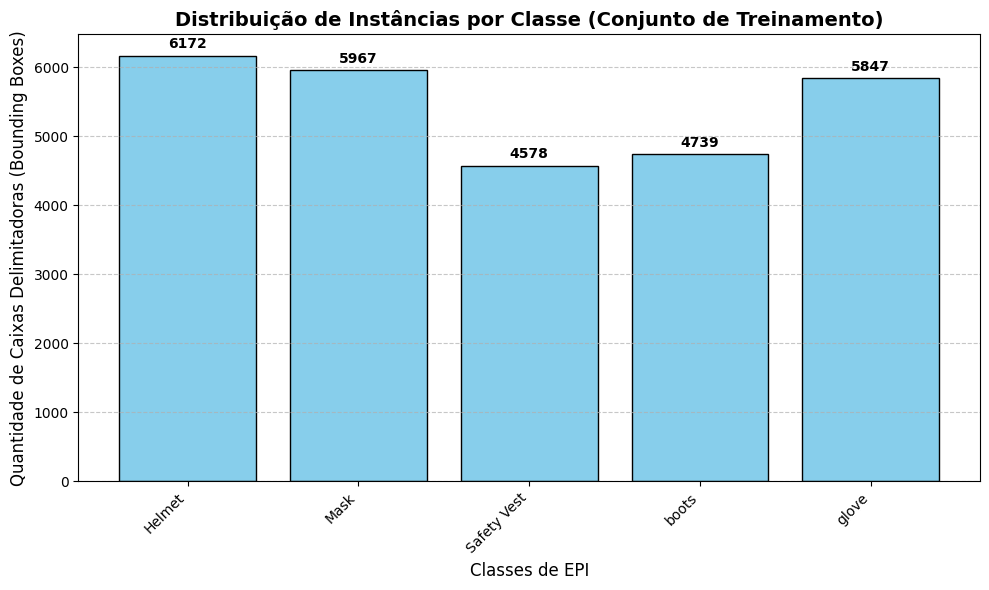


--- RESUMO DA DISTRIBUIÇÃO ---
Total de objetos anotados no treinamento: 27303
- Helmet: 6172 instâncias (22.6% do total)
- Mask: 5967 instâncias (21.9% do total)
- Safety Vest: 4578 instâncias (16.8% do total)
- boots: 4739 instâncias (17.4% do total)
- glove: 5847 instâncias (21.4% do total)


In [ ]:
import os
import glob
import yaml
import matplotlib.pyplot as plt
from collections import Counter

# 1. Carregar os nomes das classes do data.yaml
# (yaml_path e base_dir já foram definidos na Seção 1)
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config.get('names', [])
if isinstance(class_names, dict):
    # Se for um dicionário {0: 'Helmet', 1: 'Vest'}
    class_names = [class_names[i] for i in range(len(class_names))]

print(f"Classes encontradas no YAML: {class_names}")

# 2. Contar as instâncias nos arquivos de label de Treinamento
train_labels_dir = os.path.join(base_dir, 'train', 'labels')
label_files = glob.glob(f"{train_labels_dir}/*.txt")

class_counts = Counter()

for file_path in label_files:
    with open(file_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            # O primeiro valor de cada linha no YOLO é o ID da classe
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

# 3. Preparar os dados para o gráfico
counts = [class_counts.get(i, 0) for i in range(len(class_names))]

# 4. Gerar o Gráfico de Barras
plt.figure(figsize=(10, 6))
bars = plt.bar(class_names, counts, color='skyblue', edgecolor='black')

# Adicionar os números exatos em cima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts)*0.01), int(yval),
             ha='center', va='bottom', fontweight='bold')

plt.title('Distribuição de Instâncias por Classe (Conjunto de Treinamento)', fontsize=14, fontweight='bold')
plt.xlabel('Classes de EPI', fontsize=12)
plt.ylabel('Quantidade de Caixas Delimitadoras (Bounding Boxes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Análise rápida em texto
total_instances = sum(counts)
print("\n--- RESUMO DA DISTRIBUIÇÃO ---")
print(f"Total de objetos anotados no treinamento: {total_instances}")
for name, count in zip(class_names, counts):
    percentage = (count / total_instances) * 100 if total_instances > 0 else 0
    print(f"- {name}: {count} instâncias ({percentage:.1f}% do total)")

## 2. Treinamento do Modelo (POC 2.0 - Otimizado para Hardware)
Nesta versão aumentaremos o `batch` para 64, maximizando o uso dos 16GB de VRAM da GPU Tesla T4. Isso permite treinar por `50 epochs` em tempo menor, garantindo a melhor convergência do modelo.

In [ ]:
from ultralytics import YOLO
import torch

# Verifica se há GPU disponível
device = "0" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de treinamento: {device} (0 = GPU Nvidia)")

# Carrega o modelo YOLO pré-treinado
model = YOLO("yolo26n.pt")

# Inicia o treinamento com Otimizações de Hardware e Hiperparâmetros da POC 2.0
print("\nIniciando o treinamento Otimizado (POC 2.0)...")
train_results = model.train(
    data=yaml_path,
    epochs=50,           # Aumentado para 50 para tentar melhorar convergência do modelo
    imgsz=640,            # Resolução original mantida
    device=device,

    # --- OTIMIZAÇÕES DE HARDWARE (POC 2.0) ---
    cache='disk',           # Carrega imagens no disco (Pois não temos RAM suficiente para o dataset, 14gb necessario, 12gb disponivel)
    batch=64,             # Envia 64 imagens por vez para a GPU (Usa mais VRAM da T4, acelerando o processo de treinamento)
    workers=2,            # Usa 2 núcleos da CPU (Colab free) para pré-processamento

    # --- ENGENHARIA DE HIPERPARÂMETROS (Herdado da POC 1.5) ---
    optimizer='AdamW',    # Convergência mais rápida e estável
    lr0=0.002,            # Taxa de aprendizado ajustada
    mosaic=1.0,           # Força o aprendizado de objetos pequenos (luvas/botas)
    scale=0.5,            # Variação de tamanho (zoom in/out)

    project="/content/runs",
    name="poc_epi_v2.0"
)

Dispositivo de treinamento: 0 (0 = GPU Nvidia)

Iniciando o treinamento Otimizado (POC 2.0)...
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/Dataset_no_person_glasses/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_sca

## 3. Avaliação e Métricas
Após o treinamento, precisamos avaliar o quão bem o modelo aprendeu a identificar os capacetes, coletes e luvas. Vamos gerar as métricas numéricas e exibir os gráficos de validação.

Calculando métricas de validação...
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 23.7±3.2 MB/s, size: 49.6 KB)
val: Scanning /content/dataset/Dataset_no_person_glasses/val/labels.cache... 2357 images, 283 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2357/2357 659.1Mit/s 0.0s
val: /content/dataset/Dataset_no_person_glasses/val/images/Video1_223_jpg.rf.000d86979bb1a0460cf9f56f1822310c.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 148/148 6.1it/s 24.1s
                   all       2357       7877      0.881      0.798      0.865      0.576
                Helmet        889       1783       0.92      0.787      0.863      0.563
                  Mask       1183       1714      0.915       0.87      0.924      0.638
           Safety

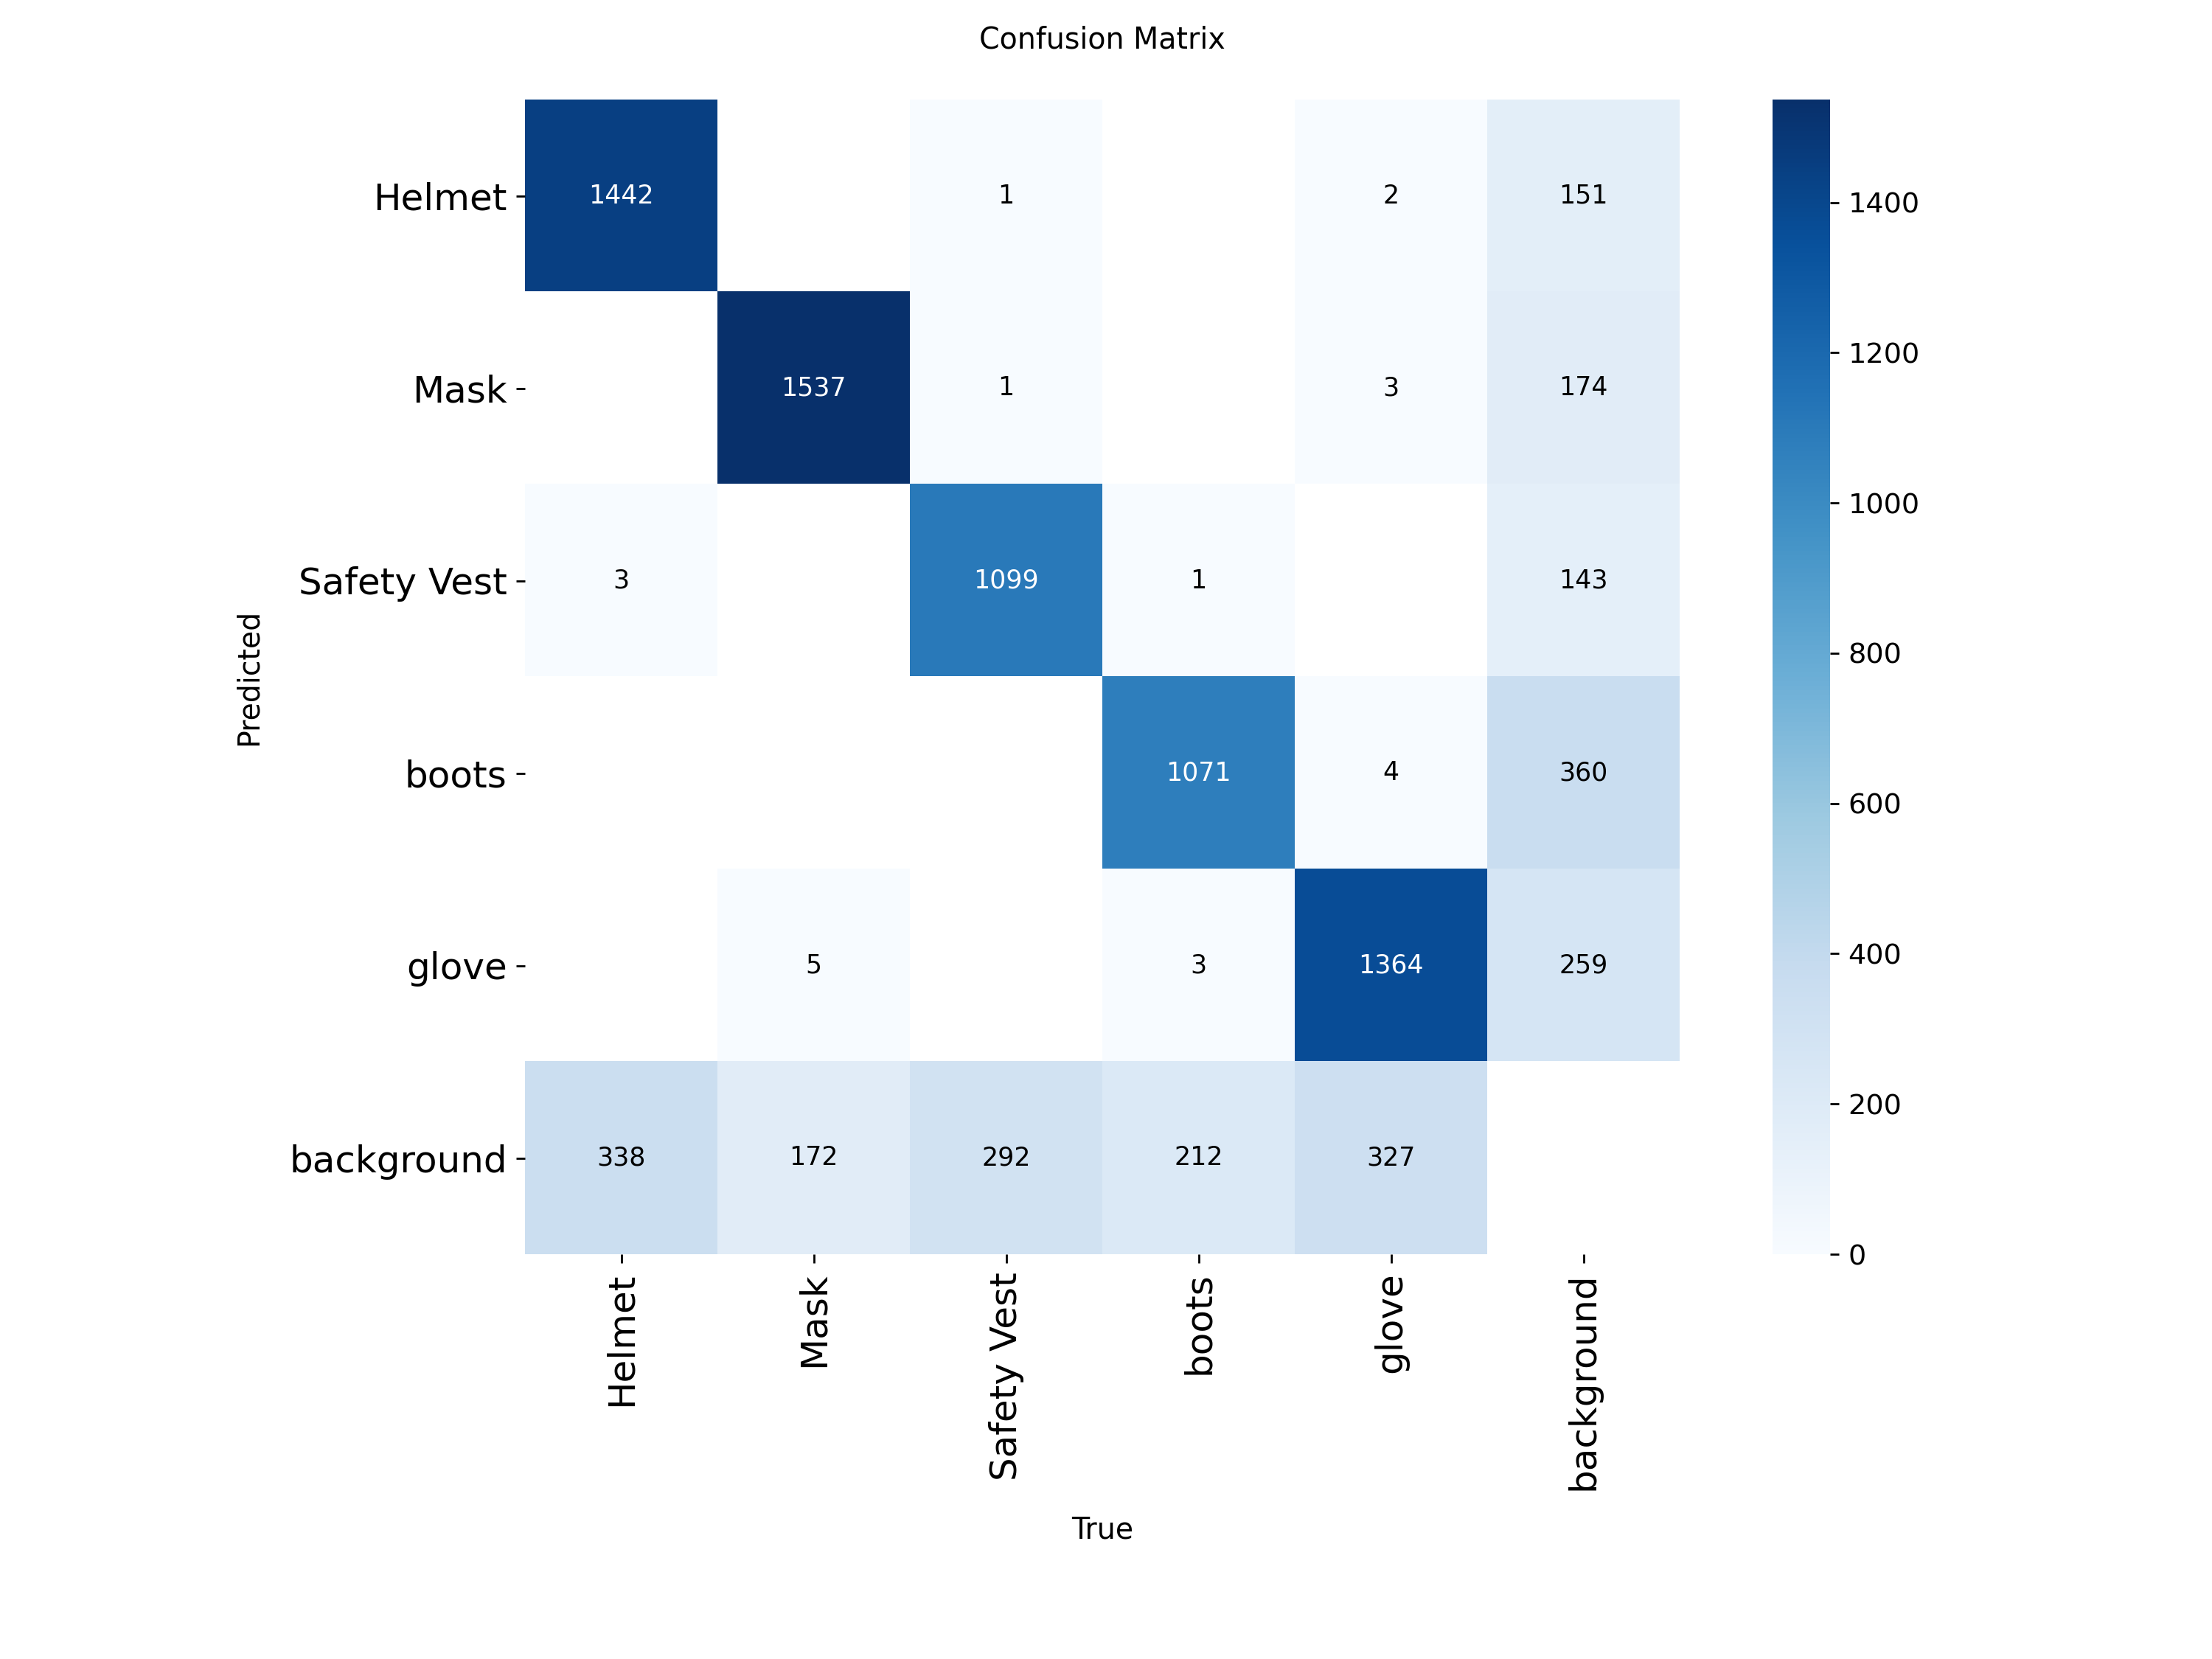


Curvas de Treinamento e Validação (Loss):


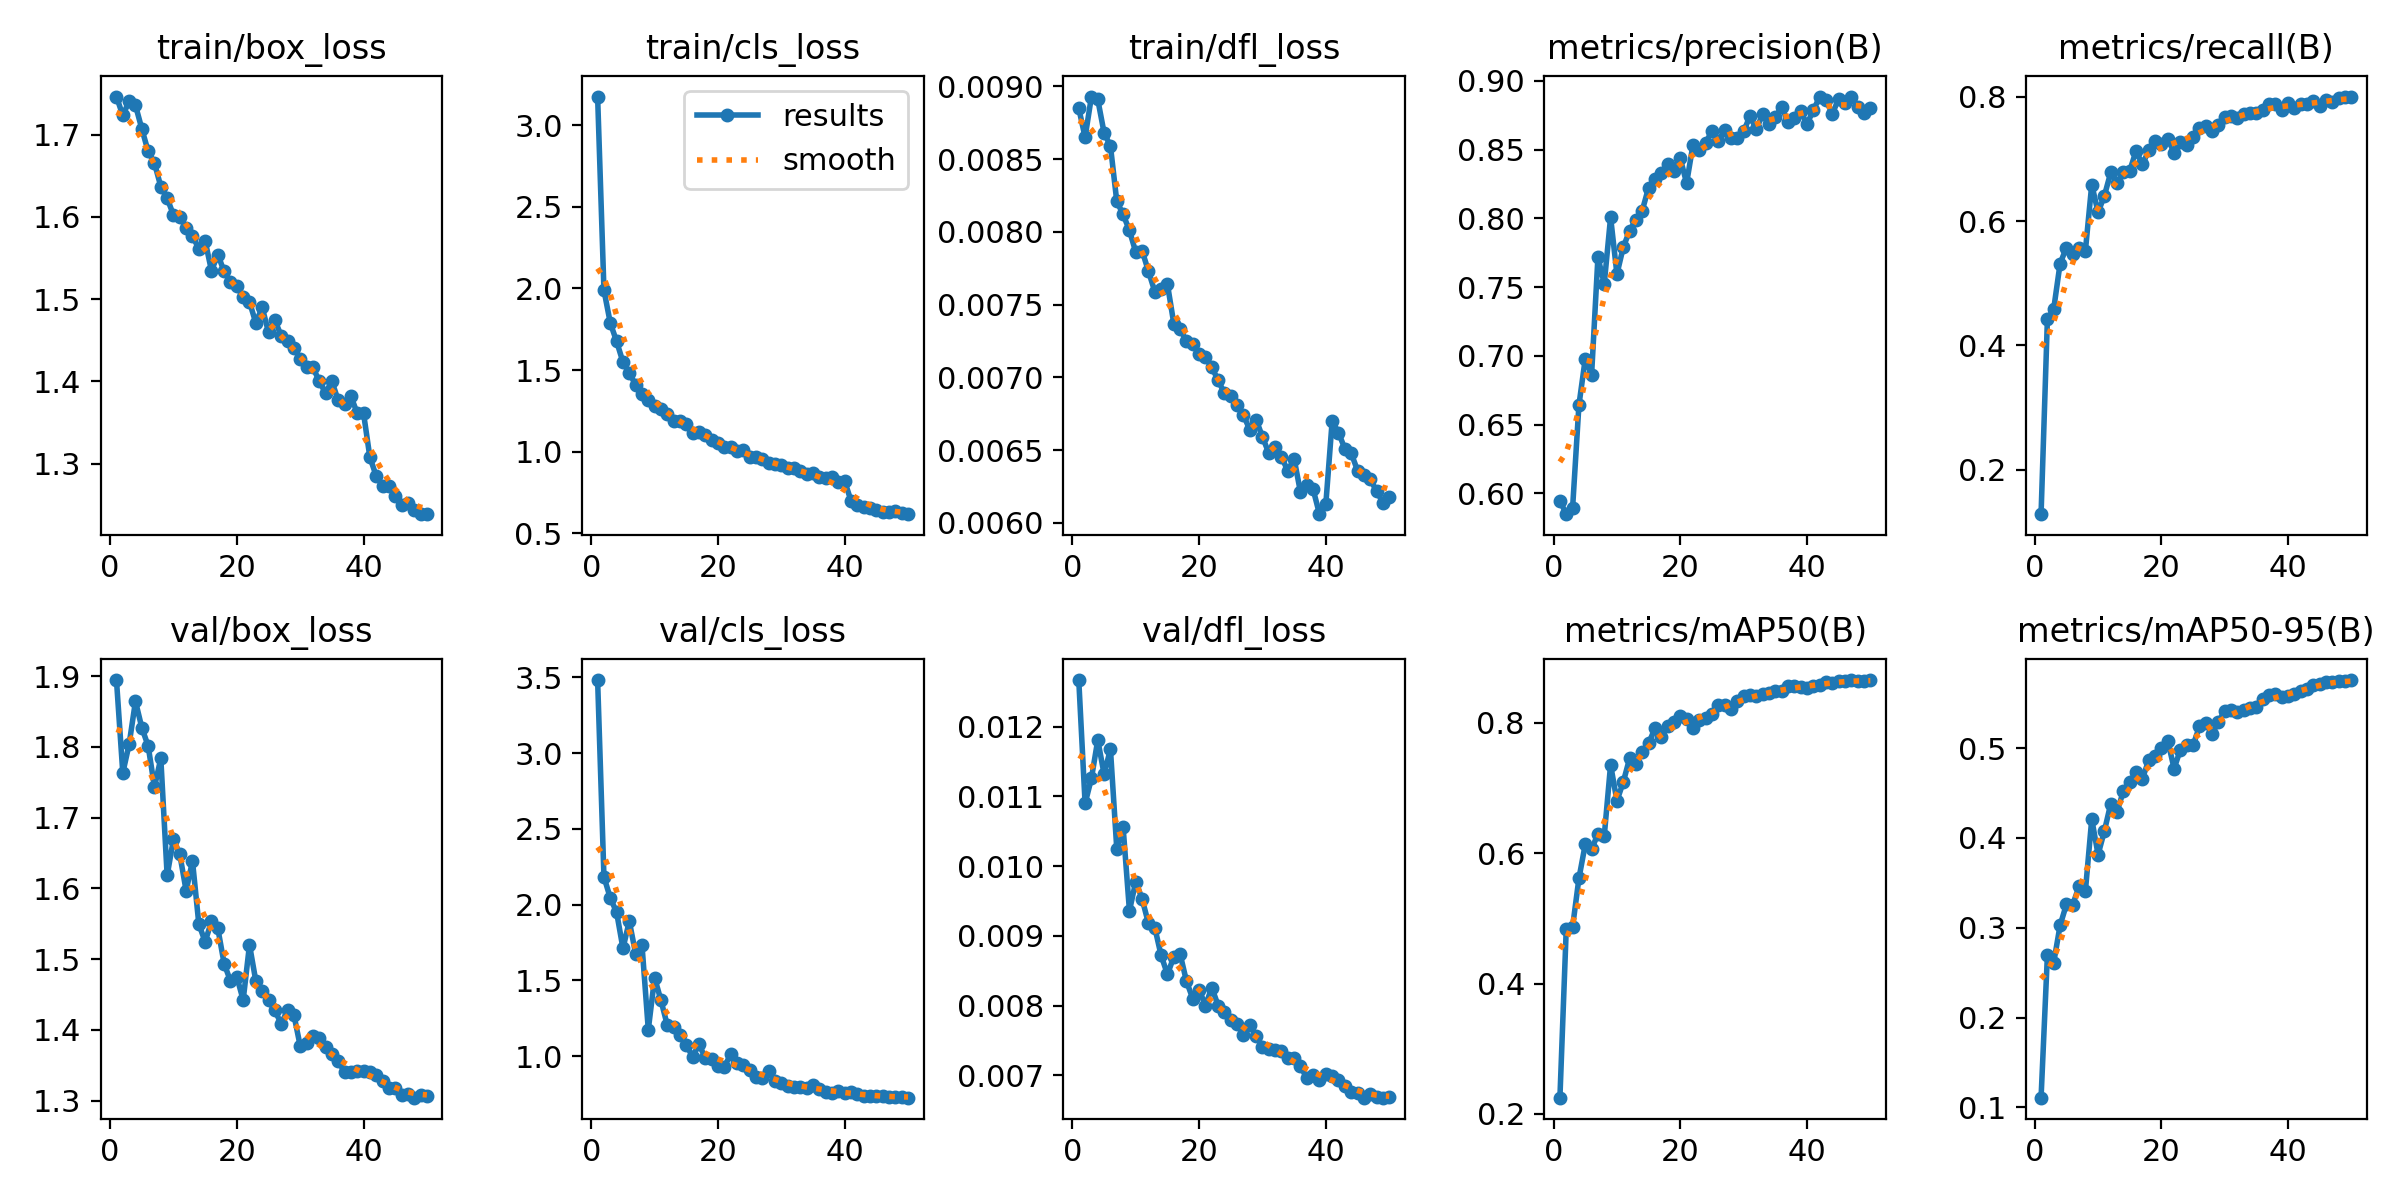


[Aviso] Gráfico 'F1_curve.png' não encontrado nas pastas de resultados.


In [ ]:
import os
import glob
from IPython.display import Image, display

# Executa a validação no conjunto de dados 'val'
print("Calculando métricas de validação...")
metrics = model.val()

print("\n--- RESULTADOS DA AVALIAÇÃO ---")
print(f"mAP50-95 (Média da Precisão Média Geral): {metrics.box.map:.4f}")
print(f"mAP50 (Precisão Média com 50% de sobreposição): {metrics.box.map50:.4f}")

# Exibindo os gráficos gerados pelo YOLO
print("\n--- GRÁFICOS DE DESEMPENHO ---")

# Função inteligente para encontrar o gráfico mais recente gerado pelo YOLO
def exibir_grafico_recente(nome_arquivo, titulo):
    # Procura o arquivo em todas as subpastas dentro de /content/runs/
    arquivos_encontrados = glob.glob(f"/content/runs/**/{nome_arquivo}", recursive=True)

    if arquivos_encontrados:
        # Se rodou mais de uma vez, pega o arquivo mais novo
        arquivo_mais_recente = max(arquivos_encontrados, key=os.path.getctime)
        print(f"\n{titulo}:")
        display(Image(filename=arquivo_mais_recente, width=800))
    else:
        print(f"\n[Aviso] Gráfico '{nome_arquivo}' não encontrado nas pastas de resultados.")

# Chama a função para exibir os 3 gráficos principais
exibir_grafico_recente("confusion_matrix.png", "Matriz de Confusão")
exibir_grafico_recente("results.png", "Curvas de Treinamento e Validação (Loss)")
exibir_grafico_recente("F1_curve.png", "Curva F1-Score (Balanço entre Precisão e Revocação)")

## 4. Demonstração do Pipeline de Processamento (Data Augmentation)

Diferente da visão computacional clássica (que utiliza filtros de cinza e suavização), modelos modernos de *Deep Learning* como o YOLO utilizam técnicas de **Aumento de Dados (Data Augmentation)**. O objetivo não é simplificar a imagem, mas sim distorcê-la durante o treinamento para forçar o modelo a aprender padrões robustos, independentemente da iluminação, escala ou oclusão.

O código abaixo demonstra visualmente as principais técnicas aplicadas na POC 1.5

Faça o upload de UMA imagem para demonstrar o pipeline de processamento:


Saving construction.png to construction.png


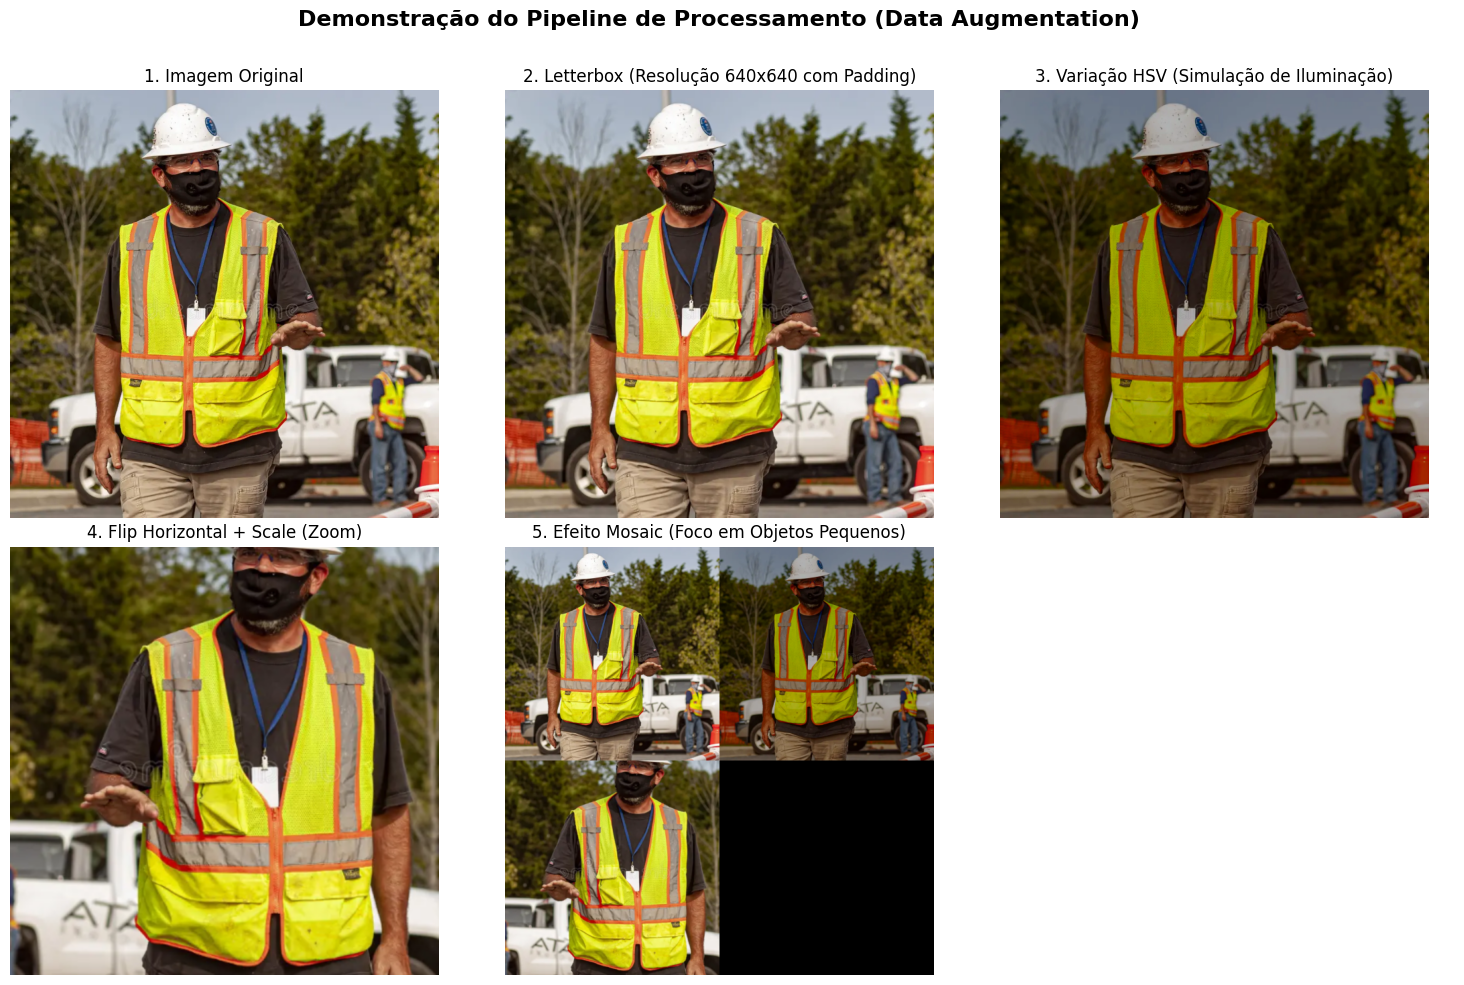

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Faça o upload de UMA imagem para demonstrar o pipeline de processamento:")
uploaded_demo = files.upload()
img_name = list(uploaded_demo.keys())[0]

# Carrega a imagem original e converte para RGB (OpenCV usa BGR por padrão)
img_bgr = cv2.imread(img_name)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# --- 1. Letterbox (Redimensionamento YOLO) ---
# O YOLO mantém a proporção da imagem e preenche o resto com cinza (padding)
def letterbox(im, new_shape=(640, 640), color=(114, 114, 114)):
    shape = im.shape[:2]  # current shape [height, width]
    r = min(new_shape[0] / shape[0], new_shape[1] / shape[1])
    new_unpad = int(round(shape[1] * r)), int(round(shape[0] * r))
    dw, dh = new_shape[1] - new_unpad[0], new_shape[0] - new_unpad[1]  # wh padding
    dw /= 2  # divide padding into 2 sides
    dh /= 2
    im = cv2.resize(im, new_unpad, interpolation=cv2.INTER_LINEAR)
    top, bottom = int(round(dh - 0.1)), int(round(dh + 0.1))
    left, right = int(round(dw - 0.1)), int(round(dw + 0.1))
    im = cv2.copyMakeBorder(im, top, bottom, left, right, cv2.BORDER_CONSTANT, value=color)
    return im

img_letterbox = letterbox(img_rgb)

# --- 2. Variação HSV (Iluminação e Cor) ---
# Simula dias nublados, sol forte ou sombras
hsv = cv2.cvtColor(img_letterbox, cv2.COLOR_RGB2HSV).astype(np.float32)
# Aumenta a saturação e diminui o brilho aleatoriamente
hsv[:, :, 1] = hsv[:, :, 1] * 1.5  # Saturação
hsv[:, :, 2] = hsv[:, :, 2] * 0.7  # Brilho (Value)
hsv = np.clip(hsv, 0, 255).astype(np.uint8)
img_hsv = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# --- 3. Flip Horizontal e Scale (Zoom) ---
# Garante reconhecimento independente do ângulo ou distância
img_flip = cv2.flip(img_letterbox, 1) # Flip horizontal
# Simula um Scale (Zoom in) cortando o centro e redimensionando
h, w = img_flip.shape[:2]
zoom_factor = 0.7
center_x, center_y = w // 2, h // 2
radius_x, radius_y = int(w * zoom_factor / 2), int(h * zoom_factor / 2)
min_x, max_x = center_x - radius_x, center_x + radius_x
min_y, max_y = center_y - radius_y, center_y + radius_y
img_cropped = img_flip[min_y:max_y, min_x:max_x]
img_scale = cv2.resize(img_cropped, (640, 640))

# --- 4. Simulação do Efeito Mosaic ---
# Vindo da POC 1.5: Junta 4 imagens para treinar objetos pequenos
# Aqui vamos simular juntando a original, a hsv, a scale e uma versão preta
mosaic = np.zeros((640, 640, 3), dtype=np.uint8)
# Reduz todas para 320x320
s = 320
mosaic[0:s, 0:s] = cv2.resize(img_letterbox, (s, s)) # Top-Left
mosaic[0:s, s:640] = cv2.resize(img_hsv, (s, s))     # Top-Right
mosaic[s:640, 0:s] = cv2.resize(img_scale, (s, s))   # Bottom-Left
# Bottom-Right deixamos preto simulando um corte agressivo do Mosaic

# --- PLOTANDO O RESULTADO ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Demonstração do Pipeline de Processamento (Data Augmentation)', fontsize=16, fontweight='bold')

# Função auxiliar para plotar
def plot_img(ax, img, title):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plot_img(axes[0, 0], img_rgb, '1. Imagem Original')
plot_img(axes[0, 1], img_letterbox, '2. Letterbox (Resolução 640x640 com Padding)')
plot_img(axes[0, 2], img_hsv, '3. Variação HSV (Simulação de Iluminação)')
plot_img(axes[1, 0], img_scale, '4. Flip Horizontal + Scale (Zoom)')
plot_img(axes[1, 1], mosaic, '5. Efeito Mosaic (Foco em Objetos Pequenos)')

# Remove o último gráfico vazio
axes[1, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

## 5. Teste Manual (Inferência)
Faça o upload de uma imagem qualquer (que não estava no dataset) de um trabalhador da construção civil para testarmos o modelo na prática. O modelo irá desenhar as caixas delimitadoras e imprimir o que encontrou.

Faça o upload de UMA imagem (.jpg ou .png) para teste manual:


Saving construction.png to construction (1).png

image 1/1 /content/construction (1).png: 640x640 2 Helmets, 2 Safety Vests, 10.8ms
Speed: 6.2ms preprocess, 10.8ms inference, 5.6ms postprocess per image at shape (1, 3, 640, 640)


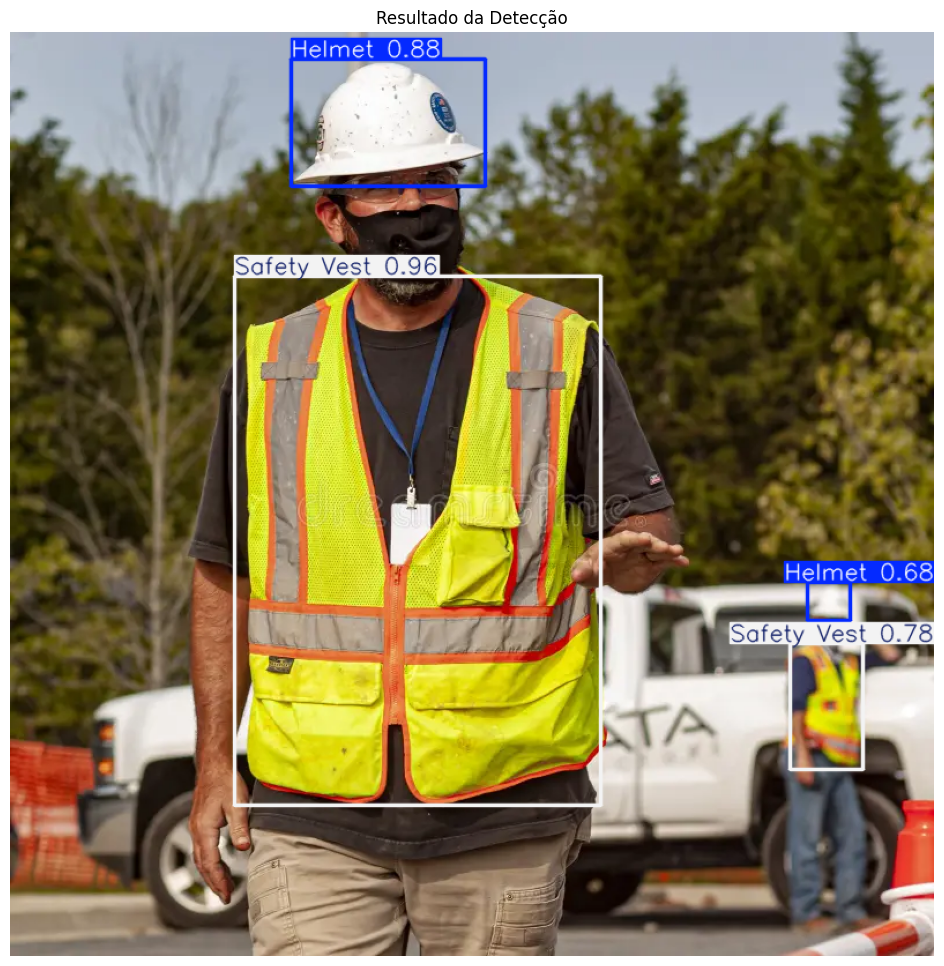


--- RELATÓRIO DE DETECÇÃO ---
Detectado: SAFETY VEST com 96.14% de confiança.
Detectado: HELMET com 88.16% de confiança.
Detectado: SAFETY VEST com 78.31% de confiança.
Detectado: HELMET com 67.71% de confiança.


In [ ]:
import cv2
import matplotlib.pyplot as plt

print("Faça o upload de UMA imagem (.jpg ou .png) para teste manual:")
uploaded_test = files.upload()
test_img_name = list(uploaded_test.keys())[0]

# Realiza a predição na imagem enviada
results = model(test_img_name)

# Extrai a imagem com as caixas desenhadas (plot)
res_plotted = results[0].plot()

# Exibe a imagem no notebook
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Resultado da Detecção")
plt.show()

# Imprime o relatório em texto
print("\n--- RELATÓRIO DE DETECÇÃO ---")
boxes = results[0].boxes
if len(boxes) == 0:
    print("Nenhum objeto detectado.")
else:
    for box in boxes:
        class_id = int(box.cls[0])
        conf = float(box.conf[0])
        class_name = model.names[class_id]
        print(f"Detectado: {class_name.upper()} com {conf*100:.2f}% de confiança.")

## 6. Exportação para Deploy (Hugging Face Spaces)
Esta seção gera automaticamente os arquivos necessários para hospedar o modelo na nuvem pública do Hugging Face. O código cria o script da interface web (`app.py`) e a lista de dependências (`requirements.txt`) e acha o arquivo `best.pt`, permitindo o download direto dos 3 para o deploy.

In [ ]:
%%writefile app.py
import gradio as gr
from ultralytics import YOLO
import cv2

# 1. Load the Model
try:
    model = YOLO('best.pt')
except Exception as e:
    print("Model not found. Make sure 'best.pt' is uploaded to the Space.")

# 2. Translation Dictionary (Default: EN)
translations = {
    "EN": {
        "title": "Automated PPE Safety Auditing",
        "subtitle": "Upload a construction site image to verify the presence of Helmets, Masks, Safety Vests, Gloves, and Boots.",
        "img_in": "Original Image (Upload)",
        "img_out": "Audit Result",
        "btn_analyze": "Analyze Image",
        "btn_clear": "Clear",
        "btn_lang": "PT-BR",
        "about_text": "### The Project Lore\nThis system was developed as a Proof of Concept (POC) for **Automated Auditing and Compliance Analysis** in the construction industry.\n\nRather than focusing on real-time monitoring, this tool is designed to analyze visual records of past events. The goal is to identify the presence or lack of PPE to support corrective actions, feedback, and targeted worker training, thereby preventing the recurrence of risky behaviors.\n\n**Technology:** Powered by a YOLO26n model, highly optimized for small object detection, occlusion scenarios, and limited hardware.\n\n**General performance metrics:** Recall: 0.798 / mAP50: 0.865 / Precision: 0.881 \n\n**Result interpretation:** Helmet 0.82 = 82% model confidence that the identified object is a helmet.",
        "report_default": "*Upload an image and click analyze to generate the audit report.*",
        "classes": ["Helmet", "Mask", "Safety Vest", "Boots", "Gloves"],
        "status_present": "✅ **Present**",
        "status_absent": "❌ **Absent**"
    },
    "PT": {
        "title": "Auditoria Automatizada de EPIs",
        "subtitle": "Faça o upload de uma imagem do canteiro de obras para verificar a presença de Capacetes, Máscaras, Coletes, Luvas e Botas.",
        "img_in": "Imagem Original (Upload)",
        "img_out": "Resultado da Auditoria",
        "btn_analyze": "Analisar Imagem",
        "btn_clear": "Limpar",
        "btn_lang": "EN-US",
        "about_text": "### O Contexto do Projeto\nEste sistema foi desenvolvido como uma Prova de Conceito (POC) para **Auditoria Automatizada e Análise de Conformidade** na construção civil.\n\nAo invés de focar em monitoramento em tempo real, esta ferramenta foi projetada para analisar registros visuais de eventos passados. O objetivo é identificar a presença ou falta de EPIs, para embasar ações corretivas, feedbacks e treinamentos direcionados aos trabalhadores, evitando a reincidência de comportamentos de risco.\n\n**Tecnologia:** Desenvolvido com um modelo YOLO26n, altamente otimizado para detecção de pequenos objetos, cenários de oclusão e limitações de hardware.\n\n**Métricas gerais de performance:** Recall: 0.798 / mAP50: 0.865 / Precision: 0.881 \n\n**Interpretação dos resultados:** Helmet 0.82 = 82% de confiança do modelo de que o objeto identificado é um capacete.",
        "report_default": "*Faça o upload de uma imagem e clique em analisar para gerar o relatório.*",
        "classes": ["Capacete", "Máscara", "Colete de Segurança", "Botas", "Luvas"],
        "status_present": "✅ **Presente**",
        "status_absent": "❌ **Ausente**"
    }
}

# --- HELPER FUNCTION: Builds the report dynamically ---
def build_report(detected_classes, lang):
    t = translations[lang]

    # If no inference has been run yet, show default text
    if detected_classes is None:
        return t["report_default"]

    report_lines = [f"### {t['img_out']}"]

    # Iterate through our 5 classes (IDs 0 to 4)
    for i, cls_name in enumerate(t["classes"]):
        status = t["status_present"] if i in detected_classes else t["status_absent"]
        report_lines.append(f"- **{cls_name}:** {status}")

    return "\n".join(report_lines)


# 3. Core Functions
def detect_epi(image, current_lang):
    if image is None:
        return None, build_report(None, current_lang), None

    # FIX: Gradio sends RGB, but YOLO wants BGR in Numpy arrays
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    # Inference: explicitly setting imgsz=640 to match documentation
    results = model(image_bgr, conf=0.40, imgsz=640)

    # Extract the image with the boxes
    res_plotted = results[0].plot()
    res_rgb = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

    # Get unique class IDs detected in the image and convert to a standard Python list
    detected_classes = list(set(results[0].boxes.cls.cpu().numpy().astype(int)))

    # Build the report text
    report_text = build_report(detected_classes, current_lang)

    # Return the image, the text, and save the detected classes in the hidden state
    return res_rgb, report_text, detected_classes

def toggle_language(current_lang, detected_classes):
    new_lang = "PT" if current_lang == "EN" else "EN"
    t = translations[new_lang]

    # Rebuild the report instantly using the saved detections and the new language
    new_report = build_report(detected_classes, new_lang)

    return (
        new_lang,
        gr.update(value=t["title"]), gr.update(value=t["subtitle"]),
        gr.update(label=t["img_in"]), gr.update(label=t["img_out"]),
        gr.update(value=t["btn_analyze"]), gr.update(value=t["btn_clear"]),
        gr.update(value=t["btn_lang"]),
        gr.update(value=t["about_text"]), gr.update(value=new_report)
    )

def clear_ui(current_lang):
    # Resets the images, the report text, and clears the hidden memory state
    return None, None, build_report(None, current_lang), None

# 4. Modern simple UI Construction
with gr.Blocks(theme=gr.themes.Soft(primary_hue="slate", neutral_hue="gray")) as app:

    # --- HIDDEN MEMORY STATES ---
    lang_state = gr.State("EN")
    detected_state = gr.State(None) # Remembers what the AI found so we can translate it

    with gr.Row(variant="panel"):
        with gr.Column(scale=4):
            title = gr.Markdown(f"# {translations['EN']['title']}")
            subtitle = gr.Markdown(translations['EN']['subtitle'])
        with gr.Column(scale=1, min_width=150):
            lang_btn = gr.Button(translations['EN']['btn_lang'], variant="secondary")

    # About Us section is now permanently visible
    about_box = gr.Markdown(translations['EN']['about_text'])

    with gr.Row():
        with gr.Column():
            img_input = gr.Image(type="numpy", label=translations['EN']['img_in'], sources=["upload"])
            with gr.Row():
                clear_btn = gr.Button(translations['EN']['btn_clear'])
                analyze_btn = gr.Button(translations['EN']['btn_analyze'], variant="primary")

        with gr.Column():
            img_output = gr.Image(type="numpy", label=translations['EN']['img_out'], interactive=False)
            report_output = gr.Markdown(translations['EN']['report_default'])

    # --- EVENT LISTENERS ---

    # Analyze button (KEEPS the loading animation because it's a real ML task)
    analyze_btn.click(
        fn=detect_epi,
        inputs=[img_input, lang_state],
        outputs=[img_output, report_output, detected_state]
    )

    # Clear button (Instant UI update)
    clear_btn.click(
        fn=clear_ui,
        inputs=lang_state,
        outputs=[img_input, img_output, report_output, detected_state],
        queue=False,
        show_progress=False
    )

    # Language button (Instant UI update)
    lang_btn.click(
        fn=toggle_language,
        inputs=[lang_state, detected_state],
        outputs=[lang_state, title, subtitle, img_input, img_output, analyze_btn, clear_btn, lang_btn, about_box, report_output],
        queue=False,
        show_progress=False
    )

if __name__ == "__main__":
    app.launch()

Writing app.py


In [ ]:
%%writefile requirements.txt
ultralytics
gradio
opencv-python-headless

Writing requirements.txt


In [ ]:
import shutil
from google.colab import files
import os

print("Preparando arquivos para o Deploy...")

# Encontra o arquivo best.pt gerado pelo treinamento
# (Ajuste 'poc_epi_v2.0' se o nome do seu projeto no model.train() for diferente)
caminho_modelo = '/content/runs/poc_epi_v2.0/weights/best.pt'

if os.path.exists(caminho_modelo):
    # Copia para a raiz para facilitar o download
    shutil.copy(caminho_modelo, '/content/best.pt')

    print("Baixando best.pt...")
    files.download('/content/best.pt')

    print("Baixando app.py...")
    files.download('/content/app.py')

    print("Baixando requirements.txt...")
    files.download('/content/requirements.txt')

    print("\n✅ Sucesso! Arraste esses 3 arquivos para o seu Hugging Face Space.")
else:
    print(f"❌ ERRO: Modelo não encontrado em {caminho_modelo}. Verifique se o treinamento terminou com sucesso.")

Preparando arquivos para o Deploy...
Baixando best.pt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Baixando app.py...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Baixando requirements.txt...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Sucesso! Arraste esses 3 arquivos para o seu Hugging Face Space.
